In [1]:
pip install fastf1 pandas

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 2.8 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 2.8 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 2.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.3/30.3 MB 2.8 MB/s  0:00:11m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 2.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 2.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 2.4 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 2.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31/31 [fastf1]28/31 [cryptography]e]zer]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import fastf1
import os

os.makedirs('cache', exist_ok=True)
fastf1.Cache.enable_cache('cache')

session = fastf1.get_session(2023, 'Silverstone', 'Q')
session.load(laps=True, telemetry=True, weather=False, messages=False)

laps = session.laps
ham_laps = laps[laps['Driver'] == 'HAM']
fastest_lap = ham_laps.loc[ham_laps['LapTime'].idxmin()]

telemetry = fastest_lap.get_telemetry()
df = telemetry[['Time', 'Speed', 'Throttle', 'Brake', 'RPM', 'nGear', 'DRS']]

print(df.head())
print(f"Total data points: {len(df)}")

/Users/gabriela.sandy/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
core           INFO 	Loading data for British Grand Prix - Qualifying [v3.7.0]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           IN

                    Time       Speed  Throttle  Brake           RPM  nGear  \
2        0 days 00:00:00  259.100000     100.0  False  10790.100000      7   
3 0 days 00:00:00.053000  260.424998     100.0  False  10844.424934      7   
4 0 days 00:00:00.116000  262.000000     100.0  False  10909.000000      7   
5 0 days 00:00:00.276000  265.000000     100.0  False  10995.000000      7   
6 0 days 00:00:00.292000  265.133333     100.0  False  11006.377778      7   

   DRS  
2    8  
3    8  
4    8  
5    8  
6    8  
Total data points: 675


In [ ]:
import hashlib
import pandas as pd
import json

# SERIALIZE setiap row jadi string lalu hash → leaf nodes
def hash_row(row):
    row_str = json.dumps({
        'Time': str(row['Time']),
        'Speed': round(float(row['Speed']), 6),
        'Throttle': round(float(row['Throttle']), 6),
        'Brake': bool(row['Brake']),
        'RPM': round(float(row['RPM']), 6),
        'nGear': int(row['nGear']),
        'DRS': int(row['DRS'])
    }, sort_keys=True)
    return hashlib.sha256(row_str.encode()).hexdigest()

leaf_hashes = [hash_row(row) for _, row in df.iterrows()]
print(f"Total leaf nodes: {len(leaf_hashes)}")
print(f"Sample leaf hash: {leaf_hashes[0]}")

# BUILD MERKLE TREE
def build_merkle_tree(leaves):
    if len(leaves) == 0:
        return []
    
    tree = [leaves]
    current_level = leaves
    
    while len(current_level) > 1:
        next_level = []
        for i in range(0, len(current_level), 2):
            left = current_level[i]
            # kalau jumlah ganjil, duplikat node terakhir
            right = current_level[i+1] if i+1 < len(current_level) else current_level[i]
            combined = hashlib.sha256((left + right).encode()).hexdigest()
            next_level.append(combined)
        tree.append(next_level)
        current_level = next_level
    
    return tree

tree = build_merkle_tree(leaf_hashes)
merkle_root = tree[-1][0]

print(f"\nMerkle Root: {merkle_root}")
print(f"Tree depth: {len(tree)} levels")

# SIMULATE TAMPERING — ubah 1 nilai speed
df_tampered = df.copy()
df_tampered.at[df_tampered.index[10], 'Speed'] = 999.0  # tamper row ke-10

tampered_hashes = [hash_row(row) for _, row in df_tampered.iterrows()]
tampered_tree = build_merkle_tree(tampered_hashes)
tampered_root = tampered_tree[-1][0]

print(f"\n── TAMPERING SIMULATION ──")
print(f"Original Root : {merkle_root}")
print(f"Tampered Root : {tampered_root}")
print(f"Integrity OK  : {merkle_root == tampered_root}")

Total leaf nodes: 675
Sample leaf hash: b58ac6cd9dff9b9073c6142fa8d33952380cb97d719074ebdaca5d84c57c310b

Merkle Root: 80848a8235ca76d5c6d435beccb1c6307922a0839ac7fa79121c87f9e4554eba
Tree depth: 11 levels

── TAMPERING SIMULATION ──
Original Root : 80848a8235ca76d5c6d435beccb1c6307922a0839ac7fa79121c87f9e4554eba
Tampered Root : e3810d8ef5d86b238885f72ead39d252fd379a11a33b39e78413dceec2805aef
Integrity OK  : False


Matplotlib is building the font cache; this may take a moment.


Merkle Proof valid untuk leaf 0: True


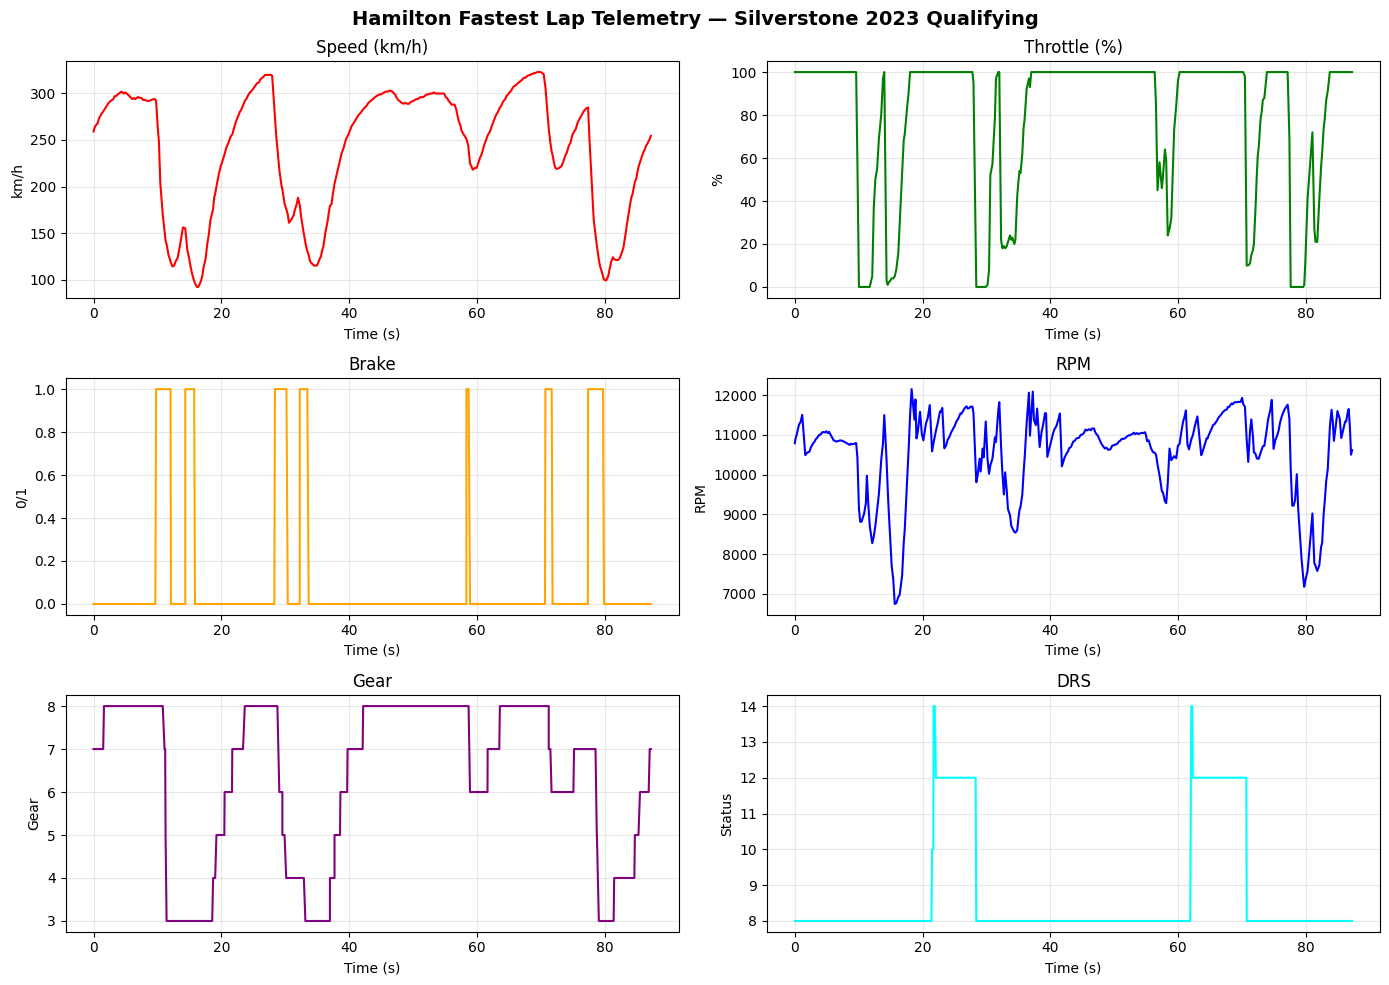

Plot saved!

── SUMMARY ──
Session       : Silverstone 2023 Qualifying
Driver        : Lewis Hamilton (HAM)
Data points   : 675
Tree depth    : 11 levels
Merkle Root   : 80848a8235ca76d5c6d435beccb1c6307922a0839ac7fa79121c87f9e4554eba
Tampered Root : e3810d8ef5d86b238885f72ead39d252fd379a11a33b39e78413dceec2805aef
Proof steps   : 10 hashes needed to verify 1 leaf


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# MERKLE PROOF — verify 1 leaf tanpa re-hash semua
def get_merkle_proof(tree, leaf_index):
    proof = []
    index = leaf_index
    for level in tree[:-1]:
        if index % 2 == 0:
            sibling = index + 1 if index + 1 < len(level) else index
            proof.append(('right', level[sibling]))
        else:
            sibling = index - 1
            proof.append(('left', level[sibling]))
        index //= 2
    return proof

def verify_merkle_proof(leaf_hash, proof, root):
    current = leaf_hash
    for direction, sibling in proof:
        if direction == 'right':
            current = hashlib.sha256((current + sibling).encode()).hexdigest()
        else:
            current = hashlib.sha256((sibling + current).encode()).hexdigest()
    return current == root

proof = get_merkle_proof(tree, 0)
is_valid = verify_merkle_proof(leaf_hashes[0], proof, merkle_root)
print(f"Merkle Proof valid untuk leaf 0: {is_valid}")

# VISUALISASI TELEMETRI
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle("Hamilton Fastest Lap Telemetry — Silverstone 2023 Qualifying", fontsize=14, fontweight='bold')

time_s = df['Time'].dt.total_seconds()

axes[0,0].plot(time_s, df['Speed'], color='red')
axes[0,0].set_title('Speed (km/h)'); axes[0,0].set_ylabel('km/h')

axes[0,1].plot(time_s, df['Throttle'], color='green')
axes[0,1].set_title('Throttle (%)'); axes[0,1].set_ylabel('%')

axes[1,0].plot(time_s, df['Brake'].astype(int), color='orange')
axes[1,0].set_title('Brake'); axes[1,0].set_ylabel('0/1')

axes[1,1].plot(time_s, df['RPM'], color='blue')
axes[1,1].set_title('RPM'); axes[1,1].set_ylabel('RPM')

axes[2,0].plot(time_s, df['nGear'], color='purple')
axes[2,0].set_title('Gear'); axes[2,0].set_ylabel('Gear')

axes[2,1].plot(time_s, df['DRS'], color='cyan')
axes[2,1].set_title('DRS'); axes[2,1].set_ylabel('Status')

for ax in axes.flat:
    ax.set_xlabel('Time (s)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('telemetry_plot.png', dpi=150)
plt.show()
print("Plot saved!")

print(f"\n── SUMMARY ──")
print(f"Session       : Silverstone 2023 Qualifying")
print(f"Driver        : Lewis Hamilton (HAM)")
print(f"Data points   : {len(df)}")
print(f"Tree depth    : {len(tree)} levels")
print(f"Merkle Root   : {merkle_root}")
print(f"Tampered Root : {tampered_root}")
print(f"Proof steps   : {len(proof)} hashes needed to verify 1 leaf")

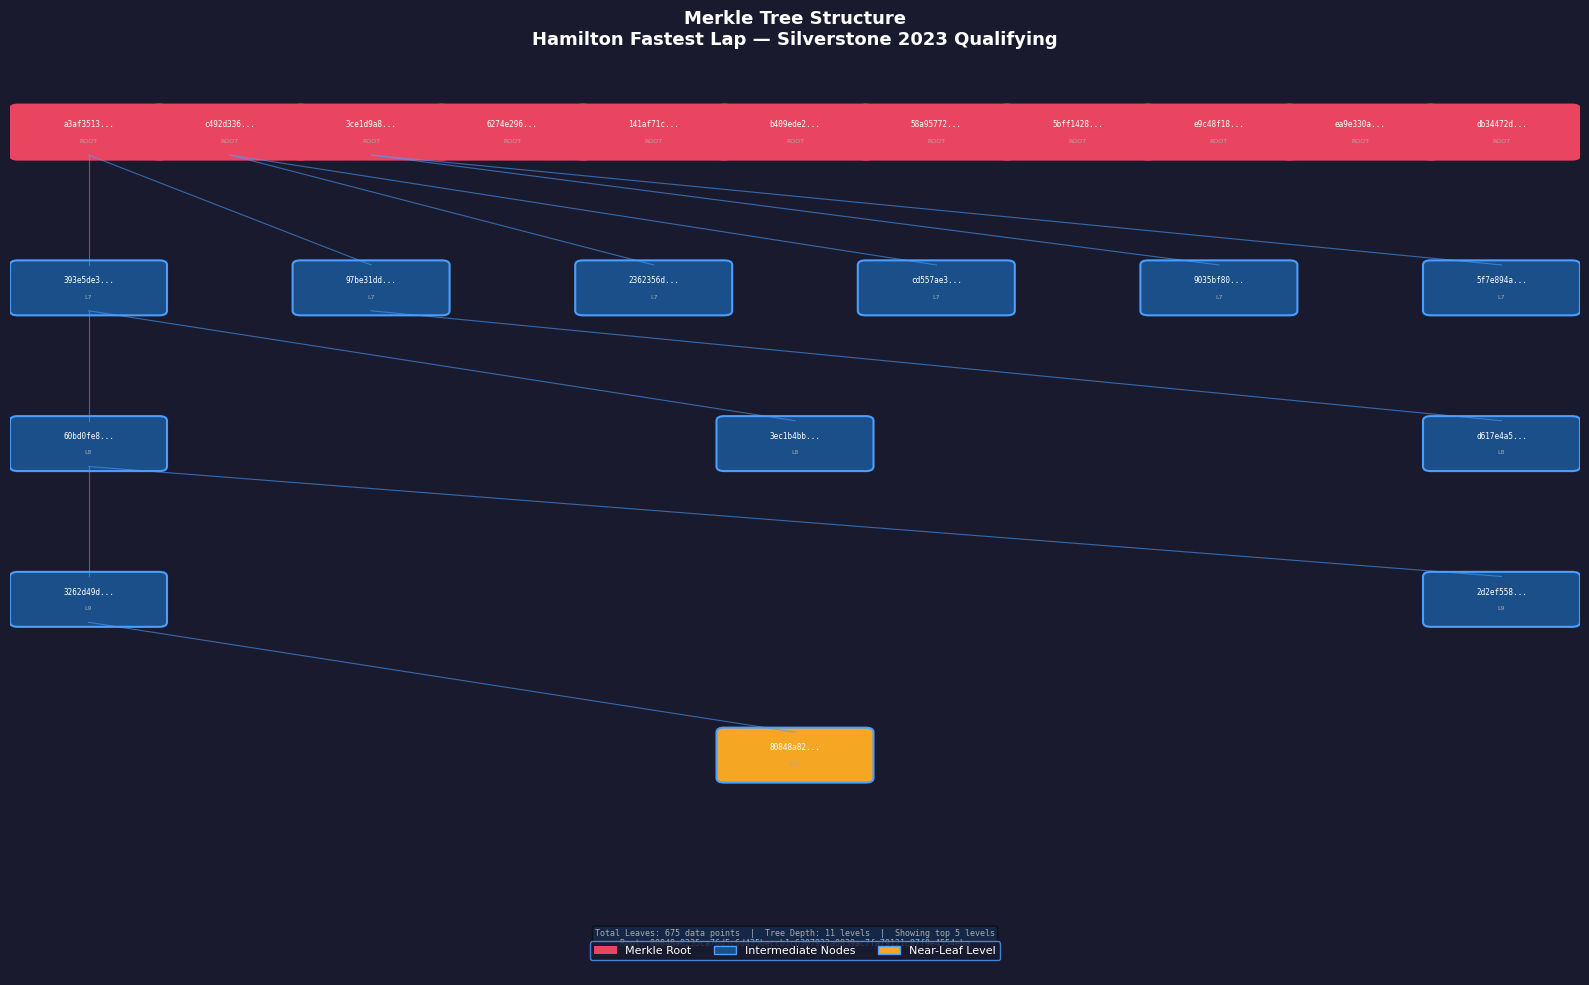

Merkle tree visualization saved!


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def visualize_merkle_tree(tree, max_display_levels=5):
    display_tree = tree[-max_display_levels:]
    num_levels = len(display_tree)
    
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    fig.patch.set_facecolor('#1a1a2e')
    ax.set_facecolor('#1a1a2e')
    
    fig.suptitle('Merkle Tree Structure\nHamilton Fastest Lap — Silverstone 2023 Qualifying',
                 fontsize=13, fontweight='bold', color='white', y=0.98)
    
    level_positions = {}
    
    for level_idx, level in enumerate(display_tree):
        y = 0.92 - (level_idx * (0.85 / num_levels))
        num_nodes = len(level)
        
        if num_nodes == 1:
            x_positions = [0.5]
        else:
            x_positions = np.linspace(0.05, 0.95, num_nodes)
        
        level_positions[level_idx] = list(zip(x_positions, [y] * num_nodes))
        
        for node_idx, (x, _) in enumerate(level_positions[level_idx]):
            hash_val = level[node_idx]
            short_hash = hash_val[:8] + '...'
            
            if level_idx == 0:
                color = '#e94560'
                label = 'ROOT'
            elif level_idx == num_levels - 1:
                color = '#f5a623'
                label = f'L{len(tree) - max_display_levels + level_idx}'
            else:
                color = '#1b4f8a'
                label = f'L{len(tree) - max_display_levels + level_idx}'
            
            box = mpatches.FancyBboxPatch(
                (x - 0.045, y - 0.025), 0.09, 0.05,
                boxstyle="round,pad=0.005",
                facecolor=color,
                edgecolor='#e94560' if level_idx == 0 else '#4a9eff',
                linewidth=1.5
            )
            ax.add_patch(box)
            
            ax.text(x, y + 0.008, short_hash,
                   ha='center', va='center',
                   fontsize=5.5, color='white',
                   fontfamily='monospace')
            ax.text(x, y - 0.01, label,
                   ha='center', va='center',
                   fontsize=4.5, color='#aaaaaa')
    
    for level_idx in range(len(display_tree) - 1):
        parent_positions = level_positions[level_idx]
        child_positions = level_positions[level_idx + 1]
        
        for p_idx, (px, py) in enumerate(parent_positions):
            left_child = p_idx * 2
            right_child = p_idx * 2 + 1
            
            for c_idx in [left_child, right_child]:
                if c_idx < len(child_positions):
                    cx, cy = child_positions[c_idx]
                    ax.plot([px, cx], [py - 0.025, cy + 0.025],
                           color='#4a9eff', linewidth=0.8, alpha=0.6)
    
    legend_elements = [
        mpatches.Patch(facecolor='#e94560', label='Merkle Root'),
        mpatches.Patch(facecolor='#1b4f8a', edgecolor='#4a9eff', label='Intermediate Nodes'),
        mpatches.Patch(facecolor='#f5a623', edgecolor='#4a9eff', label='Near-Leaf Level'),
    ]
    ax.legend(handles=legend_elements, loc='lower center',
             facecolor='#1a1a2e', edgecolor='#4a9eff',
             labelcolor='white', fontsize=8, ncol=3,
             bbox_to_anchor=(0.5, 0.01))
    
    info_text = (f'Total Leaves: 675 data points  |  '
                 f'Tree Depth: 11 levels  |  '
                 f'Showing top {max_display_levels} levels\n'
                 f'Root: 80848a8235ca76d5c6d435beccb1c6307922a0839ac7fa79121c87f9e4554eba')
    ax.text(0.5, 0.04, info_text,
           ha='center', va='center',
           fontsize=6, color='#aaaaaa',
           fontfamily='monospace',
           bbox=dict(boxstyle='round', facecolor='#0f3460', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig('merkle_tree_visualization.png', dpi=150,
                bbox_inches='tight', facecolor='#1a1a2e')
    plt.show()
    print("Merkle tree visualization saved!")

visualize_merkle_tree(tree, max_display_levels=5)

Algorithm  Avg Time (ms)  Digest Size (bits)  Hashes/sec
  SHA-256         0.2459                 256     2744521
 SHA3-256         0.2722                 256     2480056
      MD5         0.3863                 128     1747341
 SHA3-512         0.3995                 512     1689552
  SHA-512         0.5161                 512     1307786
    SHA-1         0.6025                 160     1120253


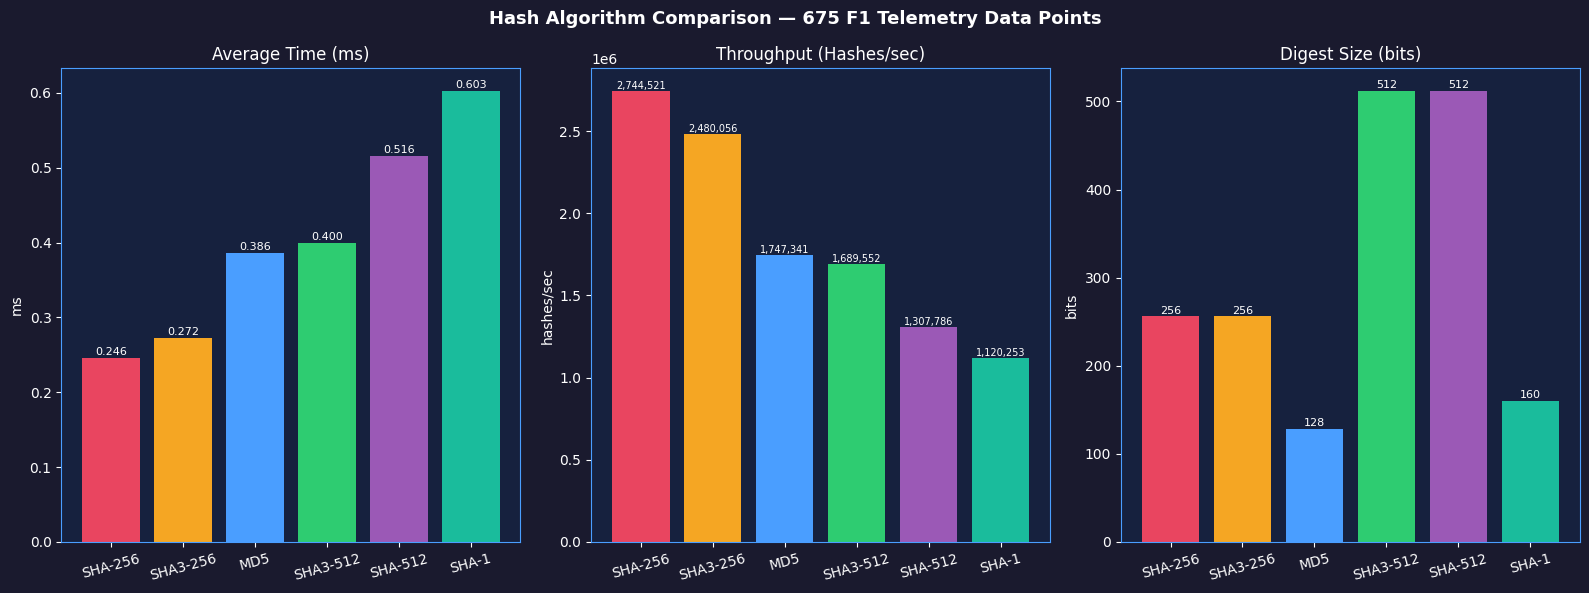

Hash comparison saved!


In [7]:
import hashlib
import time
import pandas as pd
import matplotlib.pyplot as plt
import json

def serialize_row(row):
    return json.dumps({
        'Time': str(row['Time']),
        'Speed': round(float(row['Speed']), 6),
        'Throttle': round(float(row['Throttle']), 6),
        'Brake': bool(row['Brake']),
        'RPM': round(float(row['RPM']), 6),
        'nGear': int(row['nGear']),
        'DRS': int(row['DRS'])
    }, sort_keys=True).encode()

rows = [serialize_row(row) for _, row in df.iterrows()]

algorithms = {
    'MD5':    hashlib.md5,
    'SHA-1':  hashlib.sha1,
    'SHA-256': hashlib.sha256,
    'SHA-512': hashlib.sha512,
    'SHA3-256': hashlib.sha3_256,
    'SHA3-512': hashlib.sha3_512,
}

results = []
RUNS = 100

for name, algo in algorithms.items():
    times = []
    for _ in range(RUNS):
        start = time.perf_counter()
        hashes = [algo(row).hexdigest() for row in rows]
        end = time.perf_counter()
        times.append((end - start) * 1000)
    
    avg_ms = sum(times) / len(times)
    digest_size = algo(b'').digest_size * 8
    results.append({
        'Algorithm': name,
        'Avg Time (ms)': round(avg_ms, 4),
        'Digest Size (bits)': digest_size,
        'Hashes/sec': round((675 * 1000) / avg_ms)
    })

results_df = pd.DataFrame(results).sort_values('Avg Time (ms)')
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Hash Algorithm Comparison — 675 F1 Telemetry Data Points',
             fontsize=13, fontweight='bold', color='white')

colors = ['#e94560', '#f5a623', '#4a9eff', '#2ecc71', '#9b59b6', '#1abc9c']
algos = results_df['Algorithm'].tolist()

axes[0].set_facecolor('#16213e')
bars = axes[0].bar(algos, results_df['Avg Time (ms)'], color=colors)
axes[0].set_title('Average Time (ms)', color='white')
axes[0].set_ylabel('ms', color='white')
axes[0].tick_params(colors='white', axis='both')
axes[0].set_facecolor('#16213e')
for spine in axes[0].spines.values():
    spine.set_edgecolor('#4a9eff')
for bar, val in zip(bars, results_df['Avg Time (ms)']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', color='white', fontsize=8)

axes[1].set_facecolor('#16213e')
bars2 = axes[1].bar(algos, results_df['Hashes/sec'], color=colors)
axes[1].set_title('Throughput (Hashes/sec)', color='white')
axes[1].set_ylabel('hashes/sec', color='white')
axes[1].tick_params(colors='white', axis='both')
for spine in axes[1].spines.values():
    spine.set_edgecolor('#4a9eff')
for bar, val in zip(bars2, results_df['Hashes/sec']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{val:,}', ha='center', va='bottom', color='white', fontsize=7)

axes[2].set_facecolor('#16213e')
bars3 = axes[2].bar(algos, results_df['Digest Size (bits)'], color=colors)
axes[2].set_title('Digest Size (bits)', color='white')
axes[2].set_ylabel('bits', color='white')
axes[2].tick_params(colors='white', axis='both')
for spine in axes[2].spines.values():
    spine.set_edgecolor('#4a9eff')
for bar, val in zip(bars3, results_df['Digest Size (bits)']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}', ha='center', va='bottom', color='white', fontsize=8)

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('hash_comparison.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Hash comparison saved!")